# 02 - Bias Detection and Fairness

In this section, we assess whether NovaCred’s loan approval decisions exhibit potential bias or structural fairness risks.

The analysis will examine approval outcomes across gender and age groups, evaluate intersectional effects between age and gender, and test whether geographic variables may function as proxy indicators for protected attributes.

Statistical tests and regression analysis will be used to distinguish between direct group disparities and indirect proxy effects, providing a governance-focused evaluation of fairness risk within the decision framework.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("../data/cleaned_dataset.csv")
df.head()

,spending_behavior,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,decision.interest_rate,decision.approved_amount,financials.income_unified
0,"[{'category': 'Fitness', 'amount': 576}]",Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,female,1986-05-27,90230.0,37.0,0.42,0.0,False,high_dti_ratio,NaN,NaN,102000.0
1,"[{'category': 'Education', 'amount': 533}]",Kevin Roberts,kevin.roberts9@protonmail.com,992-61-4010,172.19.95.144,male,1999-08-01,10020.0,5.0,0.36,18200.0,False,algorithm_risk_score,NaN,NaN,41000.0
2,"[{'category': 'Healthcare', 'amount': 450}]",Lisa Gonzalez,lisa.gonzalez51@yahoo.com,833-33-5929,172.21.35.195,female,1982-08-24,90213.0,74.0,0.43,7090.0,True,NaN,3.4,76000.0,65000.0
3,"[{'category': 'Transportation', 'amount': 329}...",Karen Nelson,karen.nelson35@outlook.com,486-50-5539,172.31.79.76,female,NaN,90217.0,9.0,0.41,10327.0,False,high_dti_ratio,NaN,NaN,69000.0
4,"[{'category': 'Insurance', 'amount': 585}]",Christine Mitchell,christine.mitchell3@outlook.com,400-91-8156,172.25.44.173,female,NaN,90296.0,76.0,0.06,15011.0,False,algorithm_risk_score,NaN,NaN,39000.0


In [2]:
df["applicant_info.gender"].value_counts()

applicant_info.gender
female    251
male      247
Name: count, dtype: int64

### Overview of Decision Outcomes

In [3]:
# We check the distribution of approval outcomes
df["decision.loan_approved"].value_counts(dropna=False)

decision.loan_approved
True     292
False    208
Name: count, dtype: int64

In [4]:
# We do the computation of the overall approval rate
overall_approval_rate = df["decision.loan_approved"].mean()
print(f"Overall approval rate: {overall_approval_rate:.3f}")

Overall approval rate: 0.584


### **1. Gender-Based Approval Analysis**

In [5]:
# We remove missing gender values for fairness calculation
df_gender = df.dropna(subset=["applicant_info.gender"])

gender_summary = (
    df_gender
        .groupby("applicant_info.gender")["decision.loan_approved"]
        .agg(
            approved="sum",
            total="count"
        )
)

# Then compute approval rate
gender_summary["approval_rate"] = (
    gender_summary["approved"] / gender_summary["total"]
).round(3)

gender_summary.index.name = "Gender"

gender_summary

,approved,total,approval_rate
Gender,,,
female,127,251,0.506
male,163,247,0.660


##### Disparate Impact Ratio

In [6]:
# Computation of the Disparate Impact Ratio (female as unprivileged group)
di_ratio = (
    gender_summary.loc["female", "approval_rate"] /
    gender_summary.loc["male", "approval_rate"]
)

print(f"Disparate Impact (DI) Ratio: {di_ratio:.3f}")

Disparate Impact (DI) Ratio: 0.767


The Disparate Impact (DI) ratio is calculated as the ratio of the female approval rate to the male approval rate.

Under the four-fifths rule, a DI value below 0.8 indicates potential disparate impact.

The computed DI suggests that female applicants are approved at a substantially lower rate relative to male applicants, indicating potential gender-based disparity in historical lending decisions.

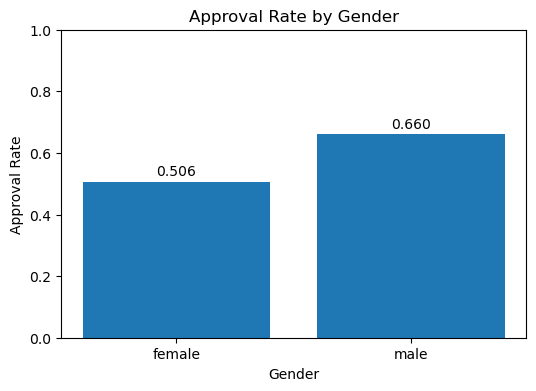

In [7]:
# We create a visualization of approval rates by gender

plt.figure(figsize=(6,4))

bars = plt.bar(
    gender_summary.index,
    gender_summary["approval_rate"]
)

plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha="center"
    )

plt.show()

The visualization confirms a noticeable disparity in approval rates between genders. Male applicants are approved at a higher rate than female applicants. This gap is consistent with the computed Disparate Impact ratio below the four-fifths threshold.

### **2. Age-based discrimination patterns**

We derive applicant age from the date of birth and then compare approval rates across age groups to detect potential age-related disparate outcomes.

In [8]:
# Calculation of the age and removing time info 
df["applicant_info.date_of_birth"] = (
    pd.to_datetime(df["applicant_info.date_of_birth"], errors="coerce")
      .dt.tz_localize(None)
)

reference_date = pd.Timestamp("2024-12-31")

df["age"] = (
    (reference_date - df["applicant_info.date_of_birth"])
    .dt.days / 365.25
).round(1)

df["age"].describe()

count    339.000000
mean      40.354277
std       11.123761
min       22.700000
25%       31.750000
50%       38.600000
75%       46.850000
max       66.300000
Name: age, dtype: float64

Valid age information is available for only 339 applicants.  
The average applicant age is approximately 40 years, with a range from 23 to 66 years.

Records with missing date of birth values are excluded from age-based fairness calculations to ensure valid subgroup comparisons.

In [9]:
# Keeping only rows with valid age
df_age = df.dropna(subset=["age"]).copy()

# Defining age bins
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18–25", "26–35", "36–45", "46–55", "56–65", "66+"]

df_age["age_group"] = pd.cut(df_age["age"], bins=bins, labels=labels)

df_age["age_group"].value_counts()

age_group
36–45    115
26–35    105
46–55     57
56–65     39
18–25     17
66+        6
Name: count, dtype: int64

**Age Group Definition:**

Age bands were constructed using standard 10-year intervals to reflect meaningful life-cycle stages (e.g., early career, mid-career, peak earnings, and pre-retirement). This structure improves interpretability and ensures that observed differences in approval rates can be assessed within a clear economic and governance context.

In [10]:
age_summary = (
    df_age
        .groupby("age_group", observed=True)["decision.loan_approved"]
        .agg(approved="sum", total="count")
)

# Adding rejected column
age_summary["rejected"] = age_summary["total"] - age_summary["approved"]

# Computation of the approval rate
age_summary["approval_rate"] = (
    age_summary["approved"] / age_summary["total"]
).round(3)

age_summary = age_summary[["approved", "rejected", "total", "approval_rate"]]

age_summary

,approved,rejected,total,approval_rate
age_group,,,,
18–25,9,8,17,0.529
26–35,46,59,105,0.438
36–45,73,42,115,0.635
46–55,37,20,57,0.649
56–65,26,13,39,0.667
66+,3,3,6,0.500


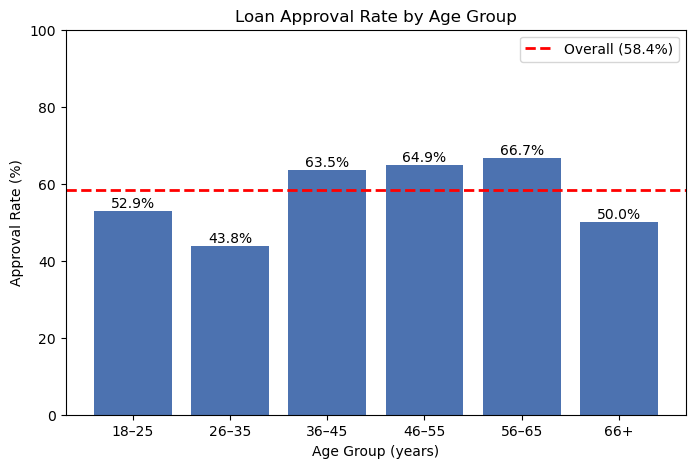

In [11]:
overall_rate = df["decision.loan_approved"].mean()
overall_rate

#  Converting approval rates to percentage
age_plot = age_summary.copy()
age_plot["approval_pct"] = age_plot["approval_rate"] * 100

overall_pct = overall_rate * 100

plt.figure(figsize=(8,5))

bars = plt.bar(
    age_plot.index.astype(str),
    age_plot["approval_pct"],
    color="#4C72B0"
)

# Adding the percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

# Including an horizontal overall approval line and label
plt.axhline(
    overall_pct,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall ({overall_pct:.1f}%)"
)

plt.title("Loan Approval Rate by Age Group")
plt.ylabel("Approval Rate (%)")
plt.xlabel("Age Group (years)")
plt.ylim(0, 100)
plt.legend()

plt.show()

Observations:

- The 26–35 group has the lowest approval rate (43.8%)
- The 56–65 group has the highest approval rate (66.7%)
- Very small group: 66+ (only 6 people → unstable rate)

Chi-square test:

Null hypothesis (H₀)

- Approval decision is independent of age group.

Alternative hypothesis (H₁)

- Approval decision depends on age group.


In [12]:
# Contingency table: age group × approval outcome
contingency_table = pd.crosstab(
    df_age["age_group"],
    df_age["decision.loan_approved"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

Chi-square statistic: 12.609
Degrees of freedom: 5
P-value: 0.0273


Statistical Test of Age-Based Differences:

A chi-square test of independence was conducted to evaluate whether loan approval decisions are associated with age group.

The test produced a chi-square statistic of 12.609 (df = 5) with a p-value of 0.0273.

Since the p-value is below the 0.05 significance threshold, we reject the null hypothesis of independence. This indicates that approval outcomes vary significantly across age groups.


### **3. Interaction effects (Age × Gender)**

In [13]:
# Keeping only rows where gender is present for the interaction analysis
df_interaction = df_age.dropna(subset=["applicant_info.gender"]).copy()

# Interaction table: age_group x gender with approved/total/approval_rate
interaction_table = (df_interaction.groupby(["age_group", "applicant_info.gender"], observed=True)["decision.loan_approved"].agg(approved="sum", total="count"))

interaction_table["approval_rate"] = (interaction_table["approved"] / interaction_table["total"]).round(3)

# Table (female vs male side-by-side)
interaction_table_wide = interaction_table.unstack("applicant_info.gender")

# Putting olumn names like approved_female, total_male, etc.
interaction_table_wide.columns = [f"{metric}_{gender}" for metric, gender in interaction_table_wide.columns]

interaction_table_wide

,approved_female,approved_male,total_female,total_male,approval_rate_female,approval_rate_male
age_group,,,,,,
18–25,6,3,12,5,0.500,0.600
26–35,21,25,57,48,0.368,0.521
36–45,30,43,50,65,0.600,0.662
46–55,17,19,29,27,0.586,0.704
56–65,12,14,20,19,0.600,0.737
66+,1,2,3,3,0.333,0.667


In [14]:
print("Total rows:", len(df))
print("Rows with valid gender:", df["applicant_info.gender"].notna().sum())
print("Rows with valid age:", df["age"].notna().sum())
print("Rows with valid age + gender:", len(df_interaction))

Total rows: 500
Rows with valid gender: 498
Rows with valid age: 339
Rows with valid age + gender: 338


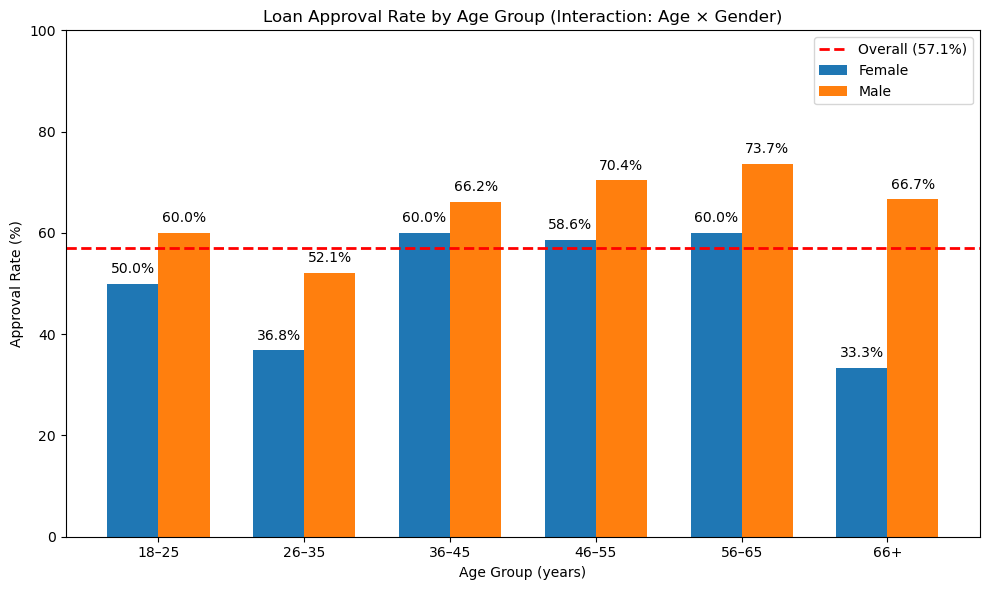

In [15]:
# Keeping rows with both age_group and gender
df_int = df_age.dropna(subset=["age_group", "applicant_info.gender", "decision.loan_approved"]).copy()

# Computing approval rate per (age_group, gender)
rates = (df_int
         .groupby(["age_group", "applicant_info.gender"], observed=True)["decision.loan_approved"]
         .mean()
         .unstack("applicant_info.gender"))  # now it's a DataFrame

# Keep only female/male columns if they exist
wanted = [c for c in ["female", "male"] if c in rates.columns]
rates = rates[wanted].reindex(labels)  # ensure correct age order

# Overall approval rate 
overall_rate = df_int["decision.loan_approved"].mean()

# (two bars per age group + overall line)
x = np.arange(len(rates.index))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars = {}
if "female" in rates.columns:
    bars["female"] = ax.bar(x - width/2, rates["female"], width, label="Female")
if "male" in rates.columns:
    bars["male"] = ax.bar(x + width/2, rates["male"], width, label="Male")

# Overall dashed line + legend label with value
ax.axhline(overall_rate,linestyle="--",linewidth=2,color="red",label=f"Overall ({overall_rate*100:.1f}%)")

# Bar labels as %
def label_bars(bar_container):
    for b in bar_container:
        h = b.get_height()
        if np.isnan(h):
            continue
        ax.text(b.get_x() + b.get_width()/2,h + 0.015,f"{h*100:.1f}%",ha="center",va="bottom",fontsize=10)

for bc in bars.values():
    label_bars(bc)

# Axes formatting 
ax.set_title("Loan Approval Rate by Age Group (Interaction: Age × Gender)")
ax.set_xlabel("Age Group (years)")
ax.set_ylabel("Approval Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(rates.index.astype(str))
ax.set_ylim(0, 1.0)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{int(v*100)}" for v in np.linspace(0, 1, 6)])

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

##### Disparate Impact Ratio

In [16]:
# Ensuring gender is standardized
df_interaction["applicant_info.gender"] = (df_interaction["applicant_info.gender"].str.lower().str.strip().replace({"m": "male", "f": "female"}))

# Compute approval rate by age group and gender
interaction_rates = (df_interaction.groupby(["age_group", "applicant_info.gender"], observed=True)["decision.loan_approved"].mean().unstack())

# Computing DI ratio (female relative to male)
interaction_rates["DI (Female / Male)"] = (interaction_rates["female"] / interaction_rates["male"]).round(3)

# Only keep DI column for final table
DI_table = interaction_rates[["DI (Female / Male)"]]
DI_table.columns.name = None
DI_table.index.name = "Age Group"

DI_table

,DI (Female / Male)
Age Group,
18–25,0.833
26–35,0.707
36–45,0.907
46–55,0.833
56–65,0.814
66+,0.500


The results show that gender disparities are not uniform across age groups. In particular, the 26–35 age group exhibits a DI of 0.707, which falls below the 0.8 threshold. This suggests that female applicants in this age segment are approved at approximately 70.7% of the male approval rate, indicating a potentially meaningful disparity.

The 66+ group displays an even lower DI (0.500); however, this category contains a very small number of observations and should therefore be interpreted with caution. Small sample sizes can produce unstable ratios and may exaggerate apparent disparities.

Other age groups remain above the four-fifths threshold, although relative differences between male and female approval rates persist. Overall, the findings suggest that gender-based disparities are amplified in certain age segments rather than evenly distributed across the population.

### **4. Proxy Discrimination Analysis**

Proxy discrimination occurs when a non-protected variable indirectly encodes a protected attribute (e.g., gender) and influences decisions in a way that reproduces disparities.

To evaluate this risk, we apply a two-step framework:

1. Proxy Potential: Does the variable strongly encode gender?
2. Proxy in Action: Does the variable independently influence approval after controlling for gender and financial risk factors?

##### **Geographic Proxy Test (ZIP → State)**

In [26]:
# Convert ZIP code to string for categorical handling
df["applicant_info.zip_code"] = df["applicant_info.zip_code"].astype(str)

# Map ZIP prefixes to states (simplified mapping for this dataset)
def zip_to_state(zip_code):
    if pd.isna(zip_code):
        return pd.NA
    prefix = zip_code[:2]
    state_map = {"10": "New York (NY)","90": "Los Angeles (CA)"}
    return state_map.get(prefix, "Other")

df["state"] = df["applicant_info.zip_code"].apply(zip_to_state)

Because the dataset includes detailed ZIP codes, we aggregate them into broader geographic clusters (states) using ZIP prefixes. 

This simplification allows clearer interpretation of geographic patterns while preserving meaningful regional differences.

We first examine whether approval rates differ across geographic groups.

In [27]:
# Approval rate by state

state_summary = (df.groupby("state")["decision.loan_approved"].agg(N="count", approved="sum"))

state_summary["approval_rate"] = (state_summary["approved"] / state_summary["N"]).round(3)

state_summary

,N,approved,approval_rate
state,,,
Los Angeles (CA),230,119,0.517
New York (NY),251,162,0.645
Other,19,11,0.579


Approval rates differ across geographic groups, with New York showing higher approval rates than Los Angeles.

However, geographic differences alone do not establish proxy discrimination. Observed disparities may reflect underlying demographic composition rather than location-based treatment.

We therefore proceed to test whether geography strongly encodes gender.

In [25]:
# Gender composition within each state

state_gender = pd.crosstab(df["state"], df["applicant_info.gender"])
state_gender_pct = state_gender.div(state_gender.sum(axis=1), axis=0).round(3)

state_gender_pct.columns.name = None
print("Gender composition within each state:")
display(state_gender_pct)

Gender composition within each state:


,female,male
state,,
Los Angeles (CA),0.935,0.065
New York (NY),0.112,0.888
Other,0.444,0.556


In [20]:
chi2, p, dof, expected = chi2_contingency(state_gender)

print("Chi-square:", round(chi2, 3))
print(f"p-value: {p:.2e}")

Chi-square: 324.668
p-value: 3.16e-71


**Association Between State and Gender**

The chi-square test evaluates whether state and gender are statistically independent.
Null hypothesis (H₀): Gender distribution is independent of state.

The test produces:
- A large chi-square statistic
- An extremely small p-value (p < 0.001)

This indicates a strong statistical dependence between geography and gender.

Gender distribution differs substantially across states (e.g., Los Angeles is predominantly female, while New York is predominantly male).

**Conclusion (Proxy Potential)**

State contains substantial gender signal and therefore qualifies as a demographic proxy for gender.

In [ ]:
# Keep only rows with state and financial variables available
proxy_df = df.dropna(subset=["state","financials.income_unified","financials.credit_history_months","financials.debt_to_income","financials.savings_balance","decision.loan_approved"]).copy()

# Binary encode state (NY vs LA)
proxy_df["state_ny"] = (proxy_df["state"] == "New York (NY)").astype(int)

# Encode gender for control
proxy_df["gender_male"] = (proxy_df["applicant_info.gender"] == "male").astype(int)

# Outcome variable
y = proxy_df["decision.loan_approved"].astype(int)

# Features (financial controls + gender + state)
X = proxy_df[["state_ny","gender_male","financials.income_unified","financials.credit_history_months","financials.debt_to_income","financials.savings_balance"]]

# Standardize numeric columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

# Extract coefficients as odds ratios
odds_ratios = np.exp(model.coef_[0])

for feature, or_value in zip(X.columns, odds_ratios):
    print(f"{feature}: OR = {or_value:.3f}")

state_ny: OR = 1.066
gender_male: OR = 1.337
financials.income_unified: OR = 1.335
financials.credit_history_months: OR = 1.257
financials.debt_to_income: OR = 1.039
financials.savings_balance: OR = 1.051


**Independent Effect on Approval (Proxy in Action)**

To determine whether geography actively drives approval decisions, we estimate a logistic regression including:

- State indicator (NY vs LA)  
- Gender  
- Financial risk variables (income, credit history, debt-to-income ratio, savings)

**Interpretation**

The state indicator (NY) corresponds to a **6.6% increase in approval odds**, holding gender and financial characteristics constant. This effect is modest.

In contrast, **male applicants exhibit 33.7% higher odds of approval** even after controlling for geography and financial risk factors, indicating a substantially stronger independent effect.

Although descriptive approval rates differ across states (64.5% in NY vs 51.7% in LA), the regression results show that once gender and financial controls are included, the independent contribution of geography is comparatively small.

**Conclusion (Proxy in Action)**

While state strongly encodes gender (as shown in the chi-square test), its independent effect on approval outcomes is limited (OR = 1.066) after controlling for demographic and financial characteristics.

This suggests that geographic differences in approval rates are largely explained by demographic composition rather than direct location-based treatment.